<a href="https://colab.research.google.com/github/sereenajoshy/AI-ML-Intership/blob/main/DAY%206/DAY_6_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile
import os
import cv2

zip_path = "/content/MRI_dataset.zip"
extract_path = "extracted_images"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Read all images
images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)

print("Total images loaded:", len(images))

Total images loaded: 506


In [2]:
import numpy as np
X = []
y = []
categories = ['no', 'yes']

for category in categories:
    path = os.path.join(extract_path, category)
    label = categories.index(category)
    for file in os.listdir(path):
        img_path = os.path.join(path, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, (128, 128))

            X.append(img)
            y.append(label)
print(len(X))
print(len(y))

253
253


In [3]:
X = np.array(X)
y = np.array(y)

In [4]:
print(X.shape)#image
print(y.shape)#label
print("No tumor:", np.sum(y==0))
print("Tumor:", np.sum(y==1))

(253, 128, 128)
(253,)
No tumor: 98
Tumor: 155


In [5]:
# CNN expect the form (number_of_images, height, width, channels) so:
X = X.reshape(-1, 128, 128, 1)
print(X.shape)

(253, 128, 128, 1)


In [6]:
X = np.array(X) / 255.0
print(X.min())
print(X.max())

0.0
1.0


In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

#80% of the images → used to teach the CNN.
#20% of the images → kept aside to test whether the CNN learned properly.

X_train: (202, 128, 128, 1)
X_test : (51, 128, 128, 1)
y_train: (202,)
y_test : (51,)


In [8]:
#from here deep learning starts

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3, 3), activation='relu',
                 input_shape=(128, 128, 1)))

# First Pooling Layer
model.add(MaxPooling2D((2, 2)))

# Second Convolution Layer
model.add(Conv2D(64, (3, 3), activation='relu'))

# Second Pooling Layer
model.add(MaxPooling2D((2, 2)))

# Convert 2D output to 1D
model.add(Flatten())

# Hidden Layer
model.add(Dense(128, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,391,873 (28.20 MB)

 Trainable params: 7,391,873 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 682ms/step - accuracy: 0.8882 - loss: 0.3290 - val_accuracy: 0.8780 - val_loss: 0.3893
Epoch 2/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 641ms/step - accuracy: 0.8882 - loss: 0.2366 - val_accuracy: 0.8293 - val_loss: 0.4125
Epoch 3/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 903ms/step - accuracy: 0.9379 - loss: 0.1562 - val_accuracy: 0.9024 - val_loss: 0.5232
Epoch 4/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 642ms/step - accuracy: 0.9379 - loss: 0.1448 - val_accuracy: 0.7805 - val_loss: 0.4480
Epoch 5/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 673ms/step - accuracy: 0.9876 - loss: 0.0801 - val_accuracy: 0.9024 - val_loss: 0.5240
Epoch 6/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 978ms/step - accuracy: 1.0000 - loss: 0.0508 - val_accuracy: 0.8780 - val_loss: 0.5344
Epoch 7/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 661ms/step - accuracy: 0.9938 - loss: 0.0389 - val_accuracy: 0.8780 - val_loss: 0.6566
Epoch 8/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 669ms/step - accuracy: 1.0000 - loss: 0.0244 - val_accuracy: 0.8780 - val_loss: 0.6884


In [19]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.8627 - loss: 0.4192
Test Accuracy: 0.8627451062202454


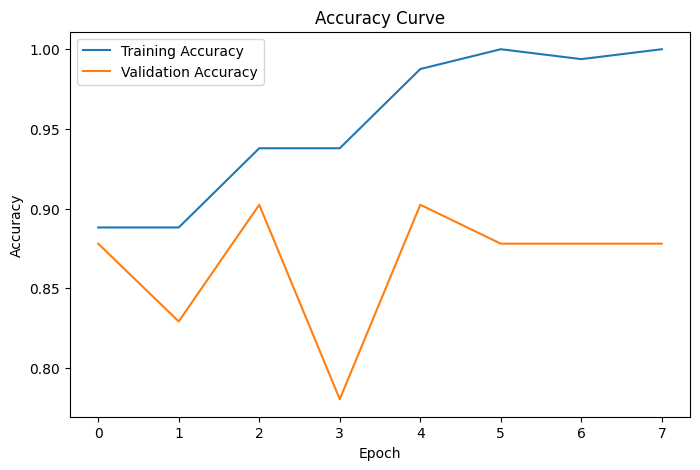

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()

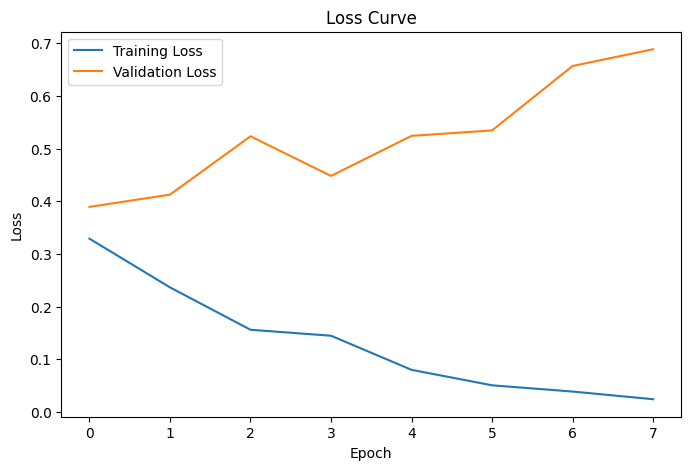

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()

In [22]:
import cv2
import numpy as np

img = cv2.imread("/content/img1.jpg", cv2.IMREAD_GRAYSCALE)

img = cv2.resize(img, (128, 128))

img = img / 255.0

img = img.reshape(1, 128, 128, 1)

In [23]:
prediction = model.predict(img)
print(prediction)

if prediction > 0.5:
    print("Tumor Detected")
else:
    print("No Tumor Detected")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
[[0.75677514]]
Tumor Detected


In [24]:
import cv2
import numpy as np

img = cv2.imread("/content/img2.webp", cv2.IMREAD_GRAYSCALE)

img = cv2.resize(img, (128, 128))

img = img / 255.0

img = img.reshape(1, 128, 128, 1)

In [25]:
prediction = model.predict(img)
print(prediction)

if prediction > 0.5:
    print("Tumor Detected")
else:
    print("No Tumor Detected")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
[[0.0667481]]
No Tumor Detected
